###### **clone repo / config sys.path**

In [ ]:
!git clone https://github.com/Denisonya/algorithms-2s.git

import sys

# прописываем путь к директории
path_to_folder = '/content/algorithms-2s'

# добавляем этот путь в sys.path, чтобы Python мог искать там модули
if path_to_folder not in sys.path:
    sys.path.append(path_to_folder)

%cd algorithms-2s/lab3

###### **imports**

In [ ]:
import importlib

# мои модули
import utils

# перезагружаем модуль
importlib.reload(utils)

from utils import time_and_memory_decorator

###### **title**

<h1></h1>

<div align="center">
  <h1><b>Министерство науки и высшего образования Российской Федерации</b></h1>

  <h1>ФЕДЕРАЛЬНОЕ ГОСУДАРСТВЕННОЕ АВТОНОМНОЕ ОБРАЗОВАТЕЛЬНОЕ УЧРЕЖДЕНИЕ ВЫСШЕГО ОБРАЗОВАНИЯ
  </h1>

  <h1><b>НАЦИОНАЛЬНЫЙ ИССЛЕДОВАТЕЛЬСКИЙ УНИВЕРСИТЕТ ИТМО</b></h1>

  <h1>ITMO University</h1>

  <h1>ФАКУЛЬТЕТ ПРИКЛАДНОЙ ИНФОРМАТИКИ</h1>

  <br><br>

  <h3>Отчет по лабораторной работе №1</h3>
  <h3>по дисциплине «Алгоритмы и структуры данных»</h3>
  <h3>Тема: Графы</h3>
  <h3>Вариант 1</h3>
</div>

<br><br>

<div align="right">
  <h5><b>Выполнил:</b></h5>
  <h5>Баранов Д.С.</h5>
  <h5>К3140</h5>

  <br>

  <h5><b>Проверил:</b></h5>
  <h5>Царьков Г.И.</h5>
</div>

<br><br>

<div align="center">
  <h5>Санкт-Петербург</h5>
  <h5>2026 г.</h5>
</div>


<h1></h1>

<div align="center">
  <h1><b>Содержание отчета</b><h1>
</div>

| Раздел                                                 | Страница |
|:-------------------------------------------------------|:--------:|
| **Задачи по варианту**                                 |    1     |
| Задача №1. Лабиринт [1 балла]                          |    1     |
| Задача №5. Город с односторонним движением [1.5 балла] |    2     |
| Задача №17. Слабая K-связность [4 балла]               |    3     |
| **Дополнительные задачи**                              |    4     |
| Задача №2. Компоненты [1 балла]                        |    4     |
| Задача №4. Топологическая сортировка [1 балла]         |    5     |
| Задача №6. Количество пересадок [1 балла]              |    5     |
| Задача №8. Стоимость полета [1.5 балла]                |    6     |
| Задача №18. Построение дорог [4 балла]                 |    7     |
| Задача №19. Кластеризация [4 балла]                    |    8     |
| **Вывод**                                              |    9     |



<h1></h1>

<div align="center">

# **Задачи по варианту**

</div>

---

### **Задача №1. Лабиринт [1 балла]**

<div align="justify">

Лабиринт представляет собой прямоугольную сетку ячеек со стенками между некоторыми соседними ячейками.
Вы хотите проверить, существует ли путь от данной ячейки к данному выходу из лабиринта, где выходом также является ячейка, лежащая на границе лабиринта (в примере, показанном на рисунке, есть два выхода: один на левой границе и один на правой границе). Для этого вы представляете лабиринт в виде неориентированного графа: вершины графа являются ячейками лабиринта, две вершины соединены неориентированным ребром, если они смежные и между ними нет стены. Тогда, чтобы проверить, существует ли путь между двумя заданными ячейками лабиринта, достаточно проверить, что существует путь между соответствующими двумя вершинами в графе.

Вам дан неориентированный граф и две различные вершины u и v. Проверьте, есть ли путь между u и v.

* **Формат ввода / входного файла (input.txt).**

Неориентированный граф с n вершинами и m ребрами задается по стандартному формату.
Следующая строка после ввода всего графа содержит две вершины u и v.

* **Ограничения на входные данные.**

2 ≤ n ≤ 10<sup>3</sup>,
1 ≤ m ≤ 10<sup>3</sup>,
1 ≤ u, v ≤ n, u ≠ v.

* **Формат вывода / выходного файла (output.txt).**

Выведите 1, если есть путь между вершинами u и v; выведите 0, если пути нет.

* **Ограничение по времени.**

5 сек.

* **Ограничение по памяти.**

512 мб.

</div>

**Листинг кода:**

In [ ]:
def dfs(n, start_node, end_node, graph):
    visited = [False for _ in range(n + 1)]  # массив посещенных вершин

    stack = [start_node]  # стек посещеенных вершин

    # пока стек не пуст продолжаем обход
    while stack:
        node = stack.pop()  # достаем верхний элемент стека

        # если уже были в данной вершине, то пропускаем ее
        if visited[node]:
            continue

        # если еще не были в данной вершине, то отмечаем ее пройденной
        visited[node] = True

        # проходим по соседям текущей вершины
        for neighbour in graph[node]:
            # если еще не посещали соседнюю вершниу
            if not visited[neighbour]:
                stack.append(neighbour)  # добавляем ее в стек для последующей обработки

    return 1 if visited[end_node] else 0  # если в итоге получилось достичь вершины end_node -> 1, иначе 0


@time_and_memory_decorator
def main():
    with open('task1/input.txt', 'r') as file_input, open('task1/output.txt', 'w') as file_output:
        n, m = map(int, file_input.readline().split())
        # сохраняем граф как список смежности
        graph = [[] for _ in range(n + 1)]  # делаем индексацию с 1
        for _ in range(m):
            a, b = map(int, file_input.readline().split())
            graph[a].append(b)
            graph[b].append(a)

        u, v = map(int, file_input.readline().split())

        result = dfs(n, u, v, graph)

        file_output.write(str(result) + '\n')


main()



**Текстовое объяснение решения:**

<div align="justify">

Чтобы узнать можно ли из одной вершины графа попасть в другую используем DFS.

**Шаги алгоритма:**
1. инициализация
    * задаем массив visited посещенных вершин
    * заводим стек посещенных вершин
2. пока стек не пуст продолжаем обход
    * достаем последнюю добавленную вершину
        * если уже были в данной вершине, то пропускаем ее
        * если нет отмечаем, что прошли через нее
    * проходим по соседям текущей вершины
        * если еще не посещали соседнюю вершниу, то добавляем ее в стек для последующей обработки

В итоге в массиве visited мы получим отмеченными 1 все вершины, в которые удалось попасть, обойдя все вершины.

</div>


**Результат работы кода на примерах из текста задачи:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
|  <img src="task1/input1.png"/>  |  <img src="task1/output1.png"/>  |
|  <img src="task1/input2.png"/>  |  <img src="task1/output2.png"/>  |
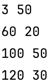

**Результат работы кода на максимальных и минимальных значениях:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
|  <img src="task1/input3.png"/>  |  <img src="task1/output3.png"/>  |

| Входные данные                                                 | Время выполнения |  Затраты памяти   |
|:---------------------------------------------------------------|:----------------:|:-----------------:|
| Нижняя граница диапазона значений входных данных (из условия)  | 0.00098 seconds  | 0.02323 megabytes |
| Пример из условия                                              | 0.00070 seconds  | 0.02303 megabytes |
| Пример из условия                                              | 0.00061 seconds  | 0.02340 megabytes |
| Верхняя граница диапазона значений входных данных (из условия) | 0.00907 seconds  | 0.16962 megabytes |

**Вывод по задаче:**

<div align="justify">

Реализован алгоритм определения существования пути из одной вершины графа в другую за время - O(n + m), где n - кол-во вершин в графе, а m - кол-во ребер в графе.

</div>

### **Задача №5. Город с односторонним движением [1.5 балла]**

<div align="justify">

Департамент полиции города сделал все улицы односторонними. Вы хотели бы проверить, можно ли законно проехать с любого перекрестка на какой-либо другой перекресток. Для этого строится ориентированный граф: вершины - это перекрестки, существует ребро (u, v) всякий раз, когда в городе есть улица (с односторонним движением) из u в v. Тогда достаточно проверить, все ли вершины графа лежат в одном компоненте сильной связности.

Нужно вычислить количество компонентов сильной связности заданного ориентированного графа с n вершинами и m ребрами.

* **Формат ввода / входного файла (input.txt).**

Ориентированный граф с n вершинами и m ребрами задается по стандартному формату.

* **Ограничения на входные данные.**

1 ≤ n ≤ 10<sup>4</sup>,
0 ≤ m ≤ 10<sup>4</sup>.

* **Формат вывода / выходного файла (output.txt).**

Выведите число - количество компонентов сильной связности.

* **Ограничение по времени.**

5 сек.

* **Ограничение по памяти.**

512 мб.

</div>

**Листинг кода:**

In [ ]:
def dfs_initial_graph(start, graph, visited, order):
    """
    Формирование порядка выхода из DFS

    start - текущая вершина
    graph - исходный граф
    visited - массив посещенных вершин
    order - список порядка выхода из графа
    """
    # False -> только зашли в вершину
    # True -> выходим из вершины
    stack = [(start, False)]  # (вершина, обработана ли она после детей)

    # пока стек не пуст продолжаем обход
    while stack:
        node, processed = stack.pop()  # достаем верхний элемент стека

        # если мы попали в эту вершину второй раз, то есть уже после обработки ее детей
        if processed:
            order.append(node)  # добавляем вершину в список выхода только после "полной" обработки вершины
            continue

        # если уже были в данной вершине, то пропускаем ее
        if visited[node]:
            continue

        # если еще не были в данной вершине, то отмечаем ее пройденной
        visited[node] = True

        # добавляем вершину обратно, чтобы обработать ее после детей
        stack.append((node, True))

        # проходим по соседям текущей вершины
        for neighbour in graph[node]:
            # если еще не посещали соседнюю вершину
            if not visited[neighbour]:
                stack.append((neighbour, False))  # добавляем ее в стек


def dfs_reversed_graph(start, rev_graph, components, cur_component):
    """
    Сборка компонент по обратному графу

    start - текущая вершина
    rev_graph - граф с перевернутыми ребрами
    components - массив c номером компоненты для каждой вершины
    cur_component - номер текущей компоненты
    """
    stack = [start]  # стек посещенных вершин

    # пока стек не пуст продолжаем обход
    while stack:
        node = stack.pop()  # достаем верхний элемент стека

        # если текущая вершина уже в компоненте, то пропускаем ее
        if components[node] != -1:
            continue

        # иначе добавляем вершину в текущую компоненту
        components[node] = cur_component

        # проходим по соседям вершины
        for neighbour in rev_graph[node]:
            # если сосед еще не входит ни в одну компоненту
            if components[neighbour] == -1:
                stack.append(neighbour)  # добавляем соседа текущей обрабатываемой вершины в стек


def first_traversal(n, graph):
    """
    Нахождение порядка выхода из графа после DFS
    """
    visited = [False for _ in range(n + 1)]  # массив посещений для вершин
    order = []  # список порядка выхода

    for v in range(1, n + 1):  # проходим по всем вершинам
        if not visited[v]:  # если вершина еще не посещена
            dfs_initial_graph(v, graph, visited, order)  # запускае DFS по исходному графу

    return order


def second_traversal(n, rev_graph, order):
    """
    Выделение компонент
    """
    components = [-1 for _ in
                  range(n + 1)]  # массив компонент (-1 означает, что вершина еще не принадлежит ни одной компоненте)
    cur_component = 0  # счетчик компонент

    # инвертируем все ребра, чтобы при следующем DFS каждая компонента выделялась отдельно и не залезала в другие компоненты
    for v in reversed(order):  # идем в обратном порядке выхода из DFS в исходном графе
        if components[v] == -1:  # если вершина еще не находится не в одной компоненте связности
            dfs_reversed_graph(v, rev_graph, components,
                               cur_component)  # запускае DFS для сбора всей компоненты этой вершины
            cur_component += 1  # переходим к следующей компоненте

    return cur_component


@time_and_memory_decorator
def main():
    with open('task5/input.txt', 'r') as file_input, open('task5/output.txt', 'w') as file_output:
        n, m = map(int, file_input.readline().split())

        # сохраняем исходный граф как список смежности
        graph = [[] for _ in range(n + 1)]

        # сохраняем обратный граф как список смежности
        rev_graph = [[] for _ in range(n + 1)]

        for _ in range(m):
            a, b = map(int, file_input.readline().split())
            graph[a].append(b)  # добавляем прямое ребро в исходный граф
            rev_graph[b].append(a)  # добавляем инвертированное ребро в обратный граф

        # поиск порядка выхода из графа через DFS
        order = first_traversal(n, graph)

        # поиск компонент
        result = second_traversal(n, rev_graph, order)  # количество компонент сильной связности

        file_output.write(str(result) + '\n')


main()

**Текстовое объяснение решения:**

<div align="justify">

Ориентированный граф называется сильно связным, если существует путь из любой вершины в любую другую вершину. Любой ориентированный граф можно разбить на компоненты сильной связности. Каждая такая компонента состоит из максимального множества вершин - такого, что существует путь из любой вершины, принадлежащей множеству, в любую другую. Эти компоненты образуют ациклический граф компонент, представляющий глубинную структуру исходного графа.

Алгоритм включает два поиска в глубину: первый строит список вершин, отражающий структуру графа, а второй формирует компоненты сильной связности.

На первом этапе алгоритма строим список вершин в порядке их посещения в процессе поиска в глубину. Перебираем все вершины исходного графа и запускаем поиск в глубину из каждой еще не обработанной. По завершении обработки вершина добавляется в список order.

На втором этапе алгоритма формируем компоненты сильной связности. Сначала инвертируем все ребра исходного графа. Это гарантирует, что в процессе второго поиска в глубину будут найдены правильные компоненты сильной связности и поиск не уйдет в другую компоненту связности.

После этого проходим по списку вершин, созданному на первом этапе, в обратном порядке. Если вершина еще не принадлежит никакой компоненте, то создаем новую компоненту связности, для этого начинаем поиск в глубину, который добавляет все найденные новые вершины в новую компоненту (поскольку все ребра инвертированы, компоненты не "просачиваются" в другие части графа).

</div>


**Результат работы кода на примерах из текста задачи:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
|  <img src="task5/input1.png"/>  |  <img src="task5/output1.png"/>  |
|  <img src="task5/input2.png"/>  |  <img src="task5/output2.png"/>  |

**Результат работы кода на максимальных и минимальных значениях:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
|  <img src="task5/input3.png"/>  |  <img src="task5/output3.png"/>  |

| Входные данные                                                 | Время выполнения |   Затраты памяти   |
|:---------------------------------------------------------------|:----------------:|:------------------:|
| Нижняя граница диапазона значений входных данных (из условия)  | 0.00078 seconds  | 0.02853 megabytes  |
| Пример из условия                                              | 0.00104 seconds  | 0.02901 megabytes  |
| Пример из условия                                              | 0.00104 seconds  | 0.02945 megabytes  |
| Верхняя граница диапазона значений входных данных (из условия) | 0.09249 seconds  | 17.11716 megabytes |

**Вывод по задаче:**

<div align="justify">

Реализован алгоритм нахождения компонент сильной связности в ориентированном ациклическом графе (алгоритм Косарайю) за время - O(n + m), где n - кол-во вершин в графе, а m - кол-во ребер в графе. Временная сложность алгоритма равна O(n + m), поскольку выполняется
два поиска в глубину.

</div>

### **Задача №17. Слабая K-связность [4 балла]**

<div align="justify">

Ане, как будущей чемпионке мира по программированию, поручили очень ответственное задание. Правительство
вручает ей план постройки дорог между N городами. По плану все дороги односторонние, но между двумя городами
может быть больше одной дороги, возможно, в разных направлениях. Ане необходимо вычислить минимальное такое
K, что данный ей план является слабо K-связным.

Правительство называет план слабо K-связным, если выполнено следующее условие: для любых двух различных
городов можно проехать от одного до другого, нарушая правила движения не более K раз. Нарушение правил - это
проезд по существующей дороге в обратном направлении. Гарантируется, что между любыми двумя городами можно
проехать, возможно, несколько раз нарушив правила.

* **Формат входных данных (input.txt) и ограничения**. В первой строке входного файла INPUT.TXT записаны
два числа 2 ≤ N ≤ 300 и 1 ≤ M ≤ 10<sup>5</sup> - количество городов и дорог в плане. В последующих M строках даны
по два числа - номера городов, в которых начинается и заканчивается соответствующая дорога.
* **Формат выходных данных (output.txt)**. В выходной файл OUTPUT.TXT выведите минимальное K, такое, что
данный во входном файле план является слабо K-связным.
* **Ограничение по времени**. 1 сек.
* **Ограничение по памяти**. 16 мб.

</div>

**Листинг кода:**

In [ ]:
from collections import deque


def zero_one_dijkstra(start, graph, n):
    """
    Поиск кратчайших путей, когда веса ребер только 0 или 1

    Замечание: мы вручную поддерживаем приоритет, добавляя вершины с наименьшей стоимостью пути до них в начало очереди

    start - стартовая вершина
    graph - исходный граф
    n - количество вершин

    Сложность: O(n + m), где n - кол-во вершин в графе, а m - кол-во ребер в графе
    """

    # минимальный расстояния до каждой вершины (минимальное число нарушений)
    distances = [10 ** 3 for _ in range(n + 1)]
    distances[start] = 0  # до самой себя расстояние = 0

    dq = deque([start])  # кладем в очередь начальную вершину

    while dq:  # пока очередь не пуста
        v = dq.popleft()  # достаем вершину из очереди, причем она будет ближайшей

        row = graph[v]  # получаем строку матрицы смежности графа для текущей вершины

        # перебираем всех соседей вершины
        for to in range(1, n + 1):
            weight = row[to]

            if weight == 2: continue  # если дороги до вершины нет

            # если нашли более короткий путь
            if distances[v] + weight < distances[to]:
                distances[to] = distances[v] + weight

                # если ребро "бесплатное", то есть проходим по направлению (без нарушений)
                if weight == 0:
                    dq.appendleft(to)  # кладем в начало, создавая приоритет
                else:
                    dq.append(to)  # кладем в конец, так как до этой вершины дальше

    return distances


@time_and_memory_decorator
def main():
    with open('task17/input.txt', 'r') as file_input, open('task17/output.txt', 'w') as file_output:
        n, m = map(int, file_input.readline().split())

        # создаем матрицу смежности для графа
        # 2 - пути нет, 0 - прямой путь, 1 - обратный (нарушение)
        # изначально заполняем пути от каждой вершины до каждой двойками (пути нет)
        graph = [[2 for _ in range(n + 1)] for _ in range(n + 1)]  # делаем индексацию с 1

        for _ in range(m):
            u, v = map(int, file_input.readline().split())

            # ПРИОРИТЕТ - если идем по направлению, то вес ребра = 0, то есть нарушений нет
            graph[u][v] = 0

            # если идем против направления и если там еще нет прямого пути, то вес ребра = 1, т.е. есть нарушение
            if graph[v][u] == 2:
                graph[v][u] = 1

        K = 0  # кол-во нарушений, которые позволят проехать из любого города в другой

        # запускаем поиск минимально пути из каждой вершины до каждой
        for start in range(1, n + 1):
            distances = zero_one_dijkstra(start, graph, n)

            # находим максимум расстояния из этой вершины
            max_dist = max(distances[1:])  # просматриваем с 1 индекса

            # обновляем общий максимум
            K = max(K, max_dist)

        file_output.write(str(K) + '\n')


main()

**Текстовое объяснение решения:**

<div align="justify">

Сначала преобразуем исходный граф в взвешенный граф:
* каждое исходное ребро u -> v: по направлению: вес = 0 (нарушения правил не происходит)
* против направления: v -> u: против напправления: вес = 1 (происходит нарушение)

Тогда длина пути от одной вершины в графе до другой показывает минимальное кол-во нарушений, которое требуется, чтобы добраться до нужной вершины.

**Алгоритм:**
* создаем массив расстояний и заполняем его бесконечностями - dist[1..n] = float('inf')
* расстояние до стартовой вершины равно 0
* создаем очередь (и добавляем начальную вершину)
* пока очередь не пуста:
    * извлекаем вершину v
    * для каждого соседа u с весом w:
        * если dist[v] + w < dist[u], обновляем dist[u] (то есть если мы нашли путь короче)
            * если w == 0 (расстоясние не увеличилось) -> кладем в начало очереди, сл-но обрабатываем быстрее
            * если w == 1 (расстоясние увеличилось на 1) -> кладём в конец очерели, сл-но обрабатываем, когда других вариантов не остается

            В итоге все вершины с расстоянием d будут в начале очереди (слева), а все вершины с расстоянием d+1 будут в конце очереди (справа).
* после опустошения очереди массив расстояний dist будет содержать минимальное число нарушений для каждой вершины от start.

Этот алгоритм запускаем для каждой вершины графа и тем самым находим минимальное число нарушений до всех остальных вершин.
Для каждой вершины графа берем максимум расстояний до всех остальных городов. Затем находим общий максимум (минимальное K) по всем вершинам, так как нам нужно иметь возможность добраться до любой вершины.

</div>


**Результат работы кода на примерах из текста задачи:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
| <img src="task17/input1.png"/>  | <img src="task17/output1.png"/>  |
| <img src="task17/input2.png"/>  | <img src="task17/output2.png"/>  |

**Результат работы кода на максимальных и минимальных значениях:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
| <img src="task17/input3.png"/>  | <img src="task17/output3.png"/>  |

**Проверка решения на acmp.ru:**

<img src="task17/acmp.png"/>

| Входные данные                                                 | Время выполнения |  Затраты памяти   |
|:---------------------------------------------------------------|:----------------:|:-----------------:|
| Нижняя граница диапазона значений входных данных (из условия)  | 0.00078 seconds  | 0.02853 megabytes |
| Пример из условия                                              | 0.00122 seconds  | 0.02795 megabytes |
| Пример из условия                                              | 0.00149 seconds  | 0.02734 megabytes |
| Верхняя граница диапазона значений входных данных (из условия) | 0.70200 seconds  | 0.76827 megabytes |

**Вывод по задаче:**

<div align="justify">

Дан ориентированный граф с N вершинами (городами) и M ребрами (дорогами). Дороги могут быть многократными и в обоих направлениях.

Граф слабо K-связный, если для любых двух вершин существует путь из одной в другую, при этом нарушать направление ребер можно не более K раз. Нарушение - проезд против направления ребра. Необходимо найти минимальное K, для которого граф слабо K-связный.

Реализован алгоритм нахождения минимального K, что граф является слабо K-связным, за время - O(n * (n + m)), где n - кол-во вершин в графе, а m - кол-во ребер в графе.

</div>

<h1></h1>

<div align="center">

# **Дополнительные задачи**

</div>

---

### **Задача №2. Компоненты [1 балла]**

<div align="justify">

Теперь вы решаете сделать так, чтобы в лабиринте не было мертвых зон, то есть чтобы из каждой клетки был
доступен хотя бы один выход. Для этого вы находите связные компоненты соответствующего неориентированного
графа и следите за тем, чтобы каждый компонент содержал выходную ячейку.

Дан неориентированный граф с n вершинами и m ребрами. Нужно посчитать количество компонент свзяности в
нем.

* **Формат ввода / входного файла (input.txt)**. Неориентированный граф с n вершинами и m ребрами по формату 1.
* **Ограничения на входные данные**. 1 ≤ n ≤ 10<sup>3</sup>, 0 ≤ m ≤ 10<sup>3</sup>.

* **Формат вывода / выходного файла (output.txt)**. Выведите количество компонент связности.
* **Ограничение по времени**. 5 сек.
* **Ограничение по памяти**. 512 мб.

</div>

**Листинг кода:**

In [ ]:
def dfs(start_node, graph, visited):
    stack = [start_node]  # стек посещенных вершин

    # пока стек не пуст продолжаем обход
    while stack:
        node = stack.pop()  # достаем верхний элемент стека

        # если уже были в данной вершине, то пропускаем ее
        if visited[node]:
            continue

        # если еще не были в данной вершине, то отмечаем ее пройденной
        visited[node] = True

        # проходим по соседям текущей вершины
        for neighbour in graph[node]:
            # если еще не посещали соседнюю вершниу
            if not visited[neighbour]:
                stack.append(neighbour)  # добавляем ее в стек для последующей обработки


@time_and_memory_decorator
def main():
    with open('task2/input.txt', 'r') as file_input, open('task2/output.txt', 'w') as file_output:
        n, m = map(int, file_input.readline().split())
        # сохраняем граф как список смежности
        graph = [[] for _ in range(n + 1)]  # делаем индексацию с 1
        for _ in range(m):
            a, b = map(int, file_input.readline().split())
            graph[a].append(b)
            graph[b].append(a)

        visited = [False for _ in range(n + 1)]  # массив посещенных вершин
        components = 0  # число компонент

        for v in range(1, n + 1):
            if not visited[v]:
                dfs(v, graph, visited)
                components += 1

        file_output.write(str(components) + '\n')


main()

**Текстовое объяснение решения:**

<div align="justify">

Перебираем вершины графа, из каждой еще не посещенной запускаем DFS. Таким образом мы за один запуск DFS обойдем одну компоненту связности. После обхода увеличиваем счетчик компонент связности.

</div>


**Результат работы кода на примерах из текста задачи:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
|  <img src="task2/input1.png"/>  |  <img src="task2/output1.png"/>  |
|  <img src="task2/input2.png"/>  |  <img src="task2/output2.png"/>  |

**Результат работы кода на максимальных и минимальных значениях:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
|  <img src="task2/input3.png"/>  |  <img src="task2/output3.png"/>  |

| Входные данные                                                 | Время выполнения |  Затраты памяти   |
|:---------------------------------------------------------------|:----------------:|:-----------------:|
| Нижняя граница диапазона значений входных данных (из условия)  | 0.00078 seconds  | 0.02337 megabytes |
| Пример из условия                                              | 0.00127 seconds  | 0.02305 megabytes |
| Пример из условия                                              | 0.00069 seconds  | 0.01993 megabytes |
| Верхняя граница диапазона значений входных данных (из условия) | 0.00533 seconds  | 0.08499 megabytes |

**Вывод по задаче:**

<div align="justify">

Реализован алгоритм нахождения количества компонент связности в неориентированном графе за время - O(n + m), где n - кол-во вершин в графе, а m - кол-во ребер в графе.

</div>

### **Задача №4. Топологическая сортировка [1 балла]**

<div align="justify">

Теперь, когда вы уверены, что в данном учебном плане нет циклических зависимостей, вам нужно найти порядок всех курсов, соответствующий всем зависимостям. Для этого нужно сделать топологическую сортировку соответствующего ориентированного графа.

Дан ориентированный ациклический граф (DAG) с n вершинами и m ребрами. Выполните топологическую сорти-
ровку.

* **Формат ввода / входного файла (input.txt)**. Ориентированный ациклический граф с n вершинами и m ребрами по формату 1.
* **Ограничения на входные данные**. 1 ≤ n ≤ 10<sup>5</sup>, 0 ≤ m ≤ 10<sup>5</sup>. Графы во входных файлах гарантированно ациклические.
* **Формат вывода / выходного файла (output.txt)**. Выведите любое линейное упорядочение данного графа (Многие ациклические графы имеют более одного варианта упорядочения, вы можете вывести любой из них).
* **Ограничение по времени**. 10 сек.
* **Ограничение по памяти**. 512 мб.

</div>

**Листинг кода:**

In [ ]:
def dfs(start_node, graph, visited, order):
    stack = [(start_node, 0)]  # стек посещенных вершин и их состояния (вершина, ее состояние)

    # пока стек не пуст продолжаем обход
    while stack:
        node, state = stack.pop()  # достаем верхний элемент стека

        if state == 0:
            # если уже были в данной вершине, то пропускаем ее
            if visited[node]:
                continue

            # если еще не были в данной вершине, то отмечаем ее пройденной
            visited[node] = True

            # добавляем вершину обратно в стек, так как мы еще из нее не вышли (перешли через нее, но не вернулись обратно)
            stack.append((node, 1))

            # проходим по соседям текущей вершины
            for neighbour in graph[node]:
                # если еще не посещали соседнюю вершниу
                if not visited[neighbour]:
                    # добавляем ее в стек для последующей обработки
                    stack.append((neighbour, 0))
        else:
            # если состояние вершины = 1 и мы обработали всех ее детей, то добавляем ее в список
            order.append(node)


@time_and_memory_decorator
def main():
    with open('task4/input.txt', 'r') as file_input, open('task4/output.txt', 'w') as file_output:
        n, m = map(int, file_input.readline().split())
        # сохраняем граф как список смежности
        graph = [[] for _ in range(n + 1)]  # делаем индексацию с 1
        for _ in range(m):
            a, b = map(int, file_input.readline().split())
            graph[a].append(b)

        visited = [False for _ in range(n + 1)]  # массив посещенных вершин
        order = []  # список вершин после сортировки

        for v in range(1, n + 1):
            if not visited[v]:
                dfs(v, graph, visited, order)

        order.reverse()  # разворачиваем полученный список, чтобы получить правильный порядок сортровки

        file_output.write(' '.join(map(str, order)) + '\n')


main()

**Текстовое объяснение решения:**

<div align="justify">

**Алгоритм топологической сортировки:**
1. создаем массив visited для отметки посещенных вершин
2. для каждой непосещенной вершины запускаем DFS
3. после того как DFS для вершины завершился, добавляем ее в список order
4. после обхода всех вершин, разворачиваем полученный список вершин, получая топологический порядок

В итоге вершины, от которых не зависит ни одна другая, будут добавлены в стек раньше.

</div>


**Результат работы кода на примерах из текста задачи:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
|  <img src="task4/input1.png"/>  |  <img src="task4/output1.png"/>  |
|  <img src="task4/input2.png"/>  |  <img src="task4/output2.png"/>  |

**Результат работы кода на максимальных и минимальных значениях:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
|  <img src="task4/input3.png"/>  |  <img src="task4/output3.png"/>  |

| Входные данные                                                 | Время выполнения |   Затраты памяти   |
|:---------------------------------------------------------------|:----------------:|:------------------:|
| Нижняя граница диапазона значений входных данных (из условия)  | 0.00091 seconds  | 0.02484 megabytes  |
| Пример из условия                                              | 0.00079 seconds  | 0.02217 megabytes  |
| Пример из условия                                              | 0.00094 seconds  | 0.02518 megabytes  |
| Верхняя граница диапазона значений входных данных (из условия) | 0.86815 seconds  | 19.18319 megabytes |

**Вывод по задаче:**

<div align="justify">

Реализован алгоритм топологической сортировки в ориентированном (в неориентированном графе топологической сортировки не существует ациклическом графе (если граф содержит цикл, тогда топологическая сортировка не возможна) за время - O(n + m), где n - кол-во вершин в графе, а m - кол-во ребер в графе.

</div>

### **Задача №6. Количество пересадок [1 балла]**

<div align="justify">

Вы хотите вычислить минимальное количество сегментов полета, чтобы добраться из одного города в другой. Для этого вы строите следующий неориентированный граф: вершины представляют города, между двумя вершинами есть ребро всякий раз, когда между соответствующими двумя городами есть перелет. Тогда достаточно найти кратчайший путь из одного из заданных городов в другой.

Дан неориентироанный граф с n вершинами и m ребрами, а также две вершины u и v, нужно посчитать длину кратчайшего пути между u и v (то есть, минимальное количество ребер в пути из u в v).

* **Формат ввода / входного файла (input.txt)**. Нериентированный граф задан по формату 1. Следующая строка содержит две вершины u и v.
* **Ограничения на входные данные**. 2 ≤ n ≤ 10<sup>5</sup>, 0 ≤ m ≤ 10<sup>5</sup>, 1 ≤ u, v ≤ n, u ̸= v.
* **Формат вывода / выходного файла (output.txt)**. Выведите минимальное количество ребер в пути из u в v. Выведите -1, если пути нет.
* **Ограничение по времени**. 10 сек.
* **Ограничение по памяти**. 512 мб.

</div>

**Листинг кода:**

In [ ]:
from collections import deque


def bfs(start, end, graph):
    visited = {start}  # посещенные вершины
    distances = {start: 0}  # расстояния до вершины
    queue = deque([start])  # добавляем начальную вершину в очередь

    # пока очередь не пуста
    while queue:
        node = queue.popleft()  # извлекаем вершину

        # если дошли до искомой вершины
        if node == end:
            return distances[node]  # возвращаем найденное растояние

        # перебираем соседей текущей вершины
        for neighbor in graph[node]:
            # если сосед еще не посещен
            if neighbor not in visited:
                visited.add(neighbor)  # запоминаем, что посетили его
                distances[neighbor] = distances[node] + 1  # запоминаем длину пути до соседа
                queue.append(neighbor)  # добавляем соседа в очередь для дальнейшей обработки

    return -1  # если пути из start в end нет


@time_and_memory_decorator
def main():
    with open('task6/input.txt', 'r') as file_input, open('task6/output.txt', 'w') as file_output:
        n, m = map(int, file_input.readline().split())
        # сохраняем граф как список смежности
        graph = [[] for _ in range(n + 1)]  # делаем индексацию с 1
        for _ in range(m):
            a, b = map(int, file_input.readline().split())
            graph[a].append(b)
            graph[b].append(a)

        u, v = map(int, file_input.readline().split())

        result = bfs(u, v, graph)

        file_output.write(str(result) + '\n')


main()

**Текстовое объяснение решения:**

<div align="justify">

Для решения задачи используем BFS, так как данный нам граф неориентированный и невзвешенный, сл-но кратчайший путь - это путь с минимальным количеством ребер.

Алгоритм BFS подходит, потому что он обходит граф по уровням, сначала рассматривая все вершины на расстоянии 1, затем на расстоянии 2, 3 и т.д. То есть первая встреча с нужной нам вершиной и будет кратчайшим путем.

**Алгоритм обхода графа в ширину:**
* Для обхода графа по уровням будем использовать очередь, а чтобы не посещать вершины повторно (если вдруг в графе есть цикл) будем хранить мн-во уже посещенных вершин. Также заведем словарь для хранения расстояний от стартовой вершины до каждой.

1. добавляем в очередь стартовую вершину start (расстояние до нее равно 0)
2. пока очередь не пуста:
    * извлекаем текущую вершину
    * если это искомая вершина end, то возвращаем расстояние
    * иначе перебираем всех соседей текущей вершины:
        * если сосед еще не посещен -> добавляем его в visited
        * записываем расстояние до соседа = расстояние до вершины, из которой пришли + 1
        * кладем в очередь соседа
3. если обход завершился и вершина end не была достигнута, то возвращаем -1

</div>


**Результат работы кода на примерах из текста задачи:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
|  <img src="task6/input1.png"/>  |  <img src="task6/output1.png"/>  |
|  <img src="task6/input2.png"/>  |  <img src="task6/output2.png"/>  |

**Результат работы кода на максимальных и минимальных значениях:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
|  <img src="task6/input3.png"/>  |  <img src="task6/output3.png"/>  |

| Входные данные                                                 | Время выполнения |   Затраты памяти   |
|:---------------------------------------------------------------|:----------------:|:------------------:|
| Нижняя граница диапазона значений входных данных (из условия)  | 0.00091 seconds  | 0.02484 megabytes  |
| Пример из условия                                              | 0.00078 seconds  | 0.02314 megabytes  |
| Пример из условия                                              | 0.00095 seconds  | 0.02332 megabytes  |
| Верхняя граница диапазона значений входных данных (из условия) | 0.86815 seconds  | 19.18319 megabytes |

**Вывод по задаче:**

<div align="justify">

Реализован алгоритм обхода графа в ширину за время - O(n + m), где n - кол-во вершин в графе, а m - кол-во ребер в графе.

</div>

### **Задача №8. Стоимость полета [1.5 балла]**

<div align="justify">

Теперь вас интересует минимизация не количества пересадок, а общей стоимости полета. Для этого строится взвешенный граф: вес ребра из одного города в другой - это стоимость соответствующего перелета.

Дан ориентированный граф с положительными весами ребер, n - количество вершин и m - количество ребер, а также даны две вершины u и v. Вычислить вес кратчайшего пути между u и v (то есть минимальный общий вес пути из u в v).

* **Формат ввода / входного файла (input.txt)**. Ориентированный взвешенный граф задан по формату 1. Следующая строка содержит две вершины u и v.
* **Ограничения на входные данные**. 1 ≤ n ≤ 10<sup>4</sup>, 0 ≤ m ≤ 10<sup>5</sup>, 1 ≤ u, v ≤ n, u ̸= v, вес каждого ребра - неотрицательное целое число, не превосходящее 10<sup>8</sup>.
* **Формат вывода / выходного файла (output.txt)**. Выведите минимальный вес пути из u в v. Веведите -1, еслипути нет.
* **Ограничение по времени**. 10 сек.
* **Ограничение по памяти**. 512 мб.

</div>

**Листинг кода:**

In [ ]:
import heapq


def dijkstra(n, start, graph):
    distances = [float('inf') for _ in range(n + 1)]  # изначально расстояния до других вершин неизвестны
    distances[start] = 0  # расстояние до начальной вершины = 0

    pq = [(0.0, start)]  # в мин приоритетную очередь добавляем картеж (расстояние до вершины, сама вершина)

    # пока очередь не пуста
    while pq:
        distance, vertex = heapq.heappop(pq)  # извлекаем из очереди ближайшую к нашему текущему состоянию вершину

        # одна и та же вершина может попасть в очередь несколько раз, но актуальное значение только в distances[vertex]
        # поэтому если достали устаревшее значение, то пропускаем
        if distance > distances[vertex]:
            continue

        # перебираем соседей вершины, чтобы провести релаксацию
        for neighbour, weight in graph[vertex]:
            # если нашли маршрут короче
            if distances[neighbour] > distances[vertex] + weight:
                # обновляем расстояние до соседа
                distances[neighbour] = distances[vertex] + weight
                # кладем соседа в очередь
                heapq.heappush(pq, (distances[neighbour], neighbour))

    return distances


@time_and_memory_decorator
def main():
    with open('task8/input.txt', 'r') as file_input, open('task8/output.txt', 'w') as file_output:
        n, m = map(int, file_input.readline().split())
        # сохраняем граф как список смежности (вершина, вес)
        graph = [[] for _ in range(n + 1)]  # делаем индексацию с 1
        for _ in range(m):
            a, b, w = map(int, file_input.readline().split())
            graph[a].append((b, w))

        u, v = map(int, file_input.readline().split())

        distances = dijkstra(n, u, graph)

        if distances[v] == float('inf'):
            file_output.write('-1\n')
        else:
            file_output.write(str(int(distances[v])) + '\n')


main()

**Текстовое объяснение решения:**

<div align="justify">

**Краткое описание алгоритма Дейкстры:**
* Каждый раз берем вершину, которую еще не рассматривали и обновляем от этой вершины все возможные пути по каждому доступному из этой вершины ребру, при этом изначально берем ближайшую вершину. Продолжаем до тех пор, пока не закончатся вершины.
* Каждый раз, когда мы начинаем обновление путей до соседей из какой-то вершины, то до этой вершины кртачайшее расстояние уже найдено.
* Это жадный алгоритм, так как мы всегда выбираем вершину с минимальным текущим состоянием и фиксируем ее, затем отталкиваемся от нее, обновляя пути до других вершин.
* Если мы уже нашли кратчайший путь до какой-то вершины, то его уже нельзя улучшить.

**Шаги алгоритма:**
1. инициализация
    * distances[vertex] = float('inf') для всех вершин
    * distances[start] = 0 для стартовой вершины
    * создаем мин приоритетную очередь pq = [(0, start)]
2. пока очередь не пуста:
    * извлекаем из нее вершину с минимальным расстоянием (distance, vertex)
    * выполняем проверку на устаревшее значение, так как одна и та же вершина может попасть в очередь несколько раз, но актуальное значение только в distances[vertex], поэтому если достали устаревшее значение, то пропускаем его
    * проходим по соседям выбранной вершины и для каждого ребра выполняем релаксацию
    * добавляем соседа (distances[neighbour], neighbour) в очередь
3. в качестве ответа выводим distances[end] или если не смогли дойти до искомой вершины, выводим -1

</div>


**Результат работы кода на примерах из текста задачи:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
|  <img src="task8/input1.png"/>  |  <img src="task8/output1.png"/>  |
|  <img src="task8/input2.png"/>  |  <img src="task8/output2.png"/>  |

**Результат работы кода на максимальных и минимальных значениях:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
|  <img src="task8/input3.png"/>  |  <img src="task8/output3.png"/>  |

| Входные данные                                                 | Время выполнения |   Затраты памяти   |
|:---------------------------------------------------------------|:----------------:|:------------------:|
| Нижняя граница диапазона значений входных данных (из условия)  | 0.00053 seconds  | 0.65630 megabytes  |
| Пример из условия                                              | 0.00098 seconds  | 0.02466 megabytes  |
| Пример из условия                                              | 0.00095 seconds  | 0.02445 megabytes  |
| Верхняя граница диапазона значений входных данных (из условия) | 0.83291 seconds  | 13.96807 megabytes |

**Вывод по задаче:**

<div align="justify">

Реализован алгоритм Дейкстры за время - O(m log n), где n - кол-во вершин в графе, а m - кол-во ребер в графе.

</div>

### **Задача №18. Построение дорог [4 балла]**

<div align="justify">

В этой задаче цель состоит в том, чтобы построить дороги между некоторыми парами заданных городов так, чтобы
между любыми двумя городами существовал путь и общая длина дорог была минимальна.

Даны n точек на плоскости, соедините их отрезками минимальной общей длины так, чтобы между любыми двумя
точками был путь. Напомним, что длина отрезка с концами (x<sub>1</sub>, y<sub>1</sub>) и (x<sub>2</sub>, y<sub>2</sub>) равна корень из
(x<sub>1</sub> − x<sub>2</sub>)<sup>2</sup> + (y<sub>1</sub> − y<sub>2</sub>)<sup>2</sup>.

* **Формат ввода / входного файла (input.txt)**. Первая строка содержит количество n точек на плоскости. Каждая
из следующих n строк определяет координаты точки на плоскости (x<sub>i</sub>, y<sub>i</sub>) через пробел.

* **Ограничения на входные данные**. 1 ≤ n ≤ 200, −10<sup>3</sup> ≤ x<sub>i</sub>, y<sub>i</sub> ≤ 10<sup>3</sup> - целые числа. Все точки попарно различны, никакие три точки не лежат на одной прямой.

* **Формат вывода / выходного файла (output.txt)**. Выведите минимальную общую длину отрезков. Абсолютная
погрешность между ответом вашей программы и оптимальным значением должно быть не более 10<sup>-6</sup>. Чтобы убедиться в этом, выведите свой ответ как минимум с семью знаками после запятой.

* **Ограничение по времени**. 10 сек.

* **Ограничение по памяти**. 512 мб.

</div>

**Листинг кода:**

In [ ]:
import math


class DSU:
    def __init__(self, n):
        self.link = [p for p in range(n)]  # представитель множества
        self.size = [1 for _ in range(n)]  # размер каждого множества

    def find(self, x):
        """
        Нахождение представителя и сжатие пути

        Сложность: O(log n)
        """
        if x == self.link[x]:
            return x
        self.link[x] = self.find(self.link[x])
        return self.link[x]

    def same(self, a, b):
        """
        Проверка принадлежности одному множеству

        Сложность: O(log n)
        """
        return self.find(a) == self.find(b)

    def unite(self, a, b):
        """
        Объединение множеств по размеру

        Сложность: O(log n)
        """
        a = self.find(a)
        b = self.find(b)

        # если вершины принадлежат одной компоненте связности
        if a == b:
            return False

        # если вершины принадлежат разным компонентам связности:

        # объединение по размеру
        if self.size[a] < self.size[b]:
            a, b = b, a

        self.link[b] = a
        self.size[a] += self.size[b]
        return True


def kruskal(n, edges):
    # сортировка ребер по возрастанию веса
    edges.sort()

    dsu = DSU(n)
    sum_distance = 0

    # построение минимального остовного дерева
    for w, a, b in edges:
        if not dsu.same(a, b):
            dsu.unite(a, b)
            sum_distance += w

    return sum_distance


@time_and_memory_decorator
def main():
    with open('task18/input.txt', 'r') as file_input, open('task18/output.txt', 'w') as file_output:
        n = int(file_input.readline())
        points = [tuple(map(int, file_input.readline().split())) for _ in range(n)]

        edges = []  # список ребер

        # построение всех ребер графа (строим полный граф)
        for i in range(n):
            for j in range(i + 1, n):
                x1, y1 = points[i]
                x2, y2 = points[j]

                dist = math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)  # вычисляем вес ребра
                edges.append((dist, i, j))  # добавляем в список ребер (вес, первая вершина, вторая вершина)

        result = kruskal(n, edges)

        file_output.write(f'{result:.9f}\n')


main()

**Текстовое объяснение решения:**

<div align="justify">

**Идея алгоритма Краскала:**

Алгоритм Краскала строит минимальное остовное дерево, жадно добавляя ребра. Изначально граф содержит все вершины и не содержит ни одного ребра. Далее ребра рассматриваются в порядке возрастания их весов. Ребро добавляется тогда и только тогда, когда оно соединяет две разные компоненты связности, то есть не образует цикл.

**Компоненты связности:**

В начале каждая вершина образует отдельную компоненту. При добавлении ребра две компоненты объединяются. В конце все вершины оказываются в одной компоненте, которая и образует минимальное остовное дерево.

**Шаги алгоритма:**

1. Построить список всех ребер графа
2. Отсортировать ребра по возрастанию веса
3. Перебирать ребра и:
    * если вершины лежат в разных компонентах, то добавляем ребро
    * иначе пропускаем это ребро

    Включать ребро с минимальным весом необходимо, если мы хотим получить минимальное остовное дерево.
4. В итоге получится минимальное остовное дерево

**Для эффективной работы алгоритма используется структура данных DSU:**

* Система непересекающихся множеств (DSU) состоит из коллекции множеств. Эти множества попарно не пересекаются, т. е. каждый элемент принадлежит только одному множеству. Поддерживаются две операции с временной сложностью O(log n): unite вычисляет объединение двух множеств, а find находит представителя множества, содержащего заданный элемент.
* В системе непересекающихся множеств в каждом множестве выбирается по одному представителю, и существует путь от любого элемента множества к его представителю.

* Поддерживаемые операции:
    * find(x) - найти представителя множества
        * Временная сложность функции find равна O(log n) в предположении, что длина каждого пути равна O(log n). В этом случае функции same и unite также работают за время O(log n). Функция unite гарантирует, что длина каждого пути будет иметь порядок O(log n), поскольку соединяет меньшее множество с большим.
    * unite(a, b) - объединить два множества
    * same(a, b) - проверить, находятся ли элементы в одном множестве (два элемента принадлежат одному и тому же множеству тогда и только тогда, когда у них одинаковые представители)

**Оптимизации:**

* объединение по размеру (меньшее множество присоединяется к большему)
    * При такой стратегии длина любого пути будет иметь порядок O(log n), так что мы сможем эффективно найти представителя любого элемента, проследовав по соответствующему пути.
* сжатие путей (сразу осуществляем переход к представителю)
     * Эта оптимизация дает амортизированное время выполнения операций системы непересекающихся множеств - O(α(n)), где α(n) - обратная функция Аккермана, т.е. почти константное время выполнения.

</div>

**Результат работы кода на примерах из текста задачи:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
| <img src="task18/input1.png"/>  | <img src="task18/output1.png"/>  |
| <img src="task18/input2.png"/>  | <img src="task18/output2.png"/>  |

**Результат работы кода на максимальных и минимальных значениях:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
| <img src="task18/input3.png"/>  | <img src="task18/output3.png"/>  |

| Входные данные                                                 | Время выполнения |  Затраты памяти   |
|:---------------------------------------------------------------|:----------------:|:-----------------:|
| Нижняя граница диапазона значений входных данных (из условия)  | 0.00111 seconds  | 0.02486 megabytes |
| Пример из условия                                              | 0.00068 seconds  | 0.99916 megabytes |
| Пример из условия                                              | 0.00071 seconds  | 0.02487 megabytes |
| Верхняя граница диапазона значений входных данных (из условия) | 0.06877 seconds  | 2.20927 megabytes |

**Вывод по задаче:**

<div align="justify">

Реализован алгоритм Краскала для поиска минимального остова графа.

**Сложность алгоритма:**
* построение ребер: O(n<sup>2</sup>)
* сортировка: O(m log m)
* операции DSU: O(α(n))
* Таким образом, временная сложность алгоритма Краскала после
сортировки списка ребер будет равна O(m log n)
* итоговая сложность алгоритма: O(n<sup>2</sup> log n)

</div>

### **Задача №19. Кластеризация [4 балла]**

<div align="justify">

Кластеризация является фундаментальной задачей интеллектуального анализа данных. Цель заключается в том, чтобы разбить данный набор объектов на подмножества (или кластеры) таким образом, чтобы любые два объекта из одного и того же подмножества были близки (или похожи) друг к другу, а любые два объекта из разных подмножеств находились далеко друг от друга.

Даны n точек на плоскости и целое число k, вычислите максимально возможное значение d, чтобы данные точки можно было разбить на непустые подмножества таким образом, чтобы расстояние между любыми двумя точками из разных подмножеств было не менее d.

* **Формат ввода / входного файла (input.txt)**. Первая строка содержит число n точек. Далее, следующие n строк
определяют координаты точек (x<sub>i</sub>, y<sub>i</sub>) через пробел. Последняя строка содержит число k - количество кластеров.

* **Ограничения на входные данные**. 2 ≤ k ≤ n ≤ 200, −10<sup>3</sup> ≤ x<sub>i</sub>, y<sub>i</sub> ≤ 10<sup>3</sup> - целые числа. Все точки попарно различны.

* **Формат вывода / выходного файла (output.txt)**. Выведите наибольшее значение d. Абсолютная погрешность
между ответом вашей программы и оптимальным значением должно быть не более 10<sup>-6</sup>. Чтобы убедиться в этом, выведите свой ответ как минимум с семью знаками после запятой.

* **Ограничение по времени**. 10 сек.

* **Ограничение по памяти**. 512 мб.

</div>

**Листинг кода:**

In [ ]:
import math


class DSU:
    def __init__(self, n):
        self.link = [p for p in range(n)]  # представитель множества
        self.size = [1 for _ in range(n)]  # размер каждого множества
        self.components = n  # число компонент связности

    def find(self, x):
        """
        Нахождение представителя и сжатие пути

        Сложность: O(log n)
        """
        if x == self.link[x]:
            return x
        self.link[x] = self.find(self.link[x])
        return self.link[x]

    def same(self, a, b):
        """
        Проверка принадлежности одному множеству

        Сложность: O(log n)
        """
        return self.find(a) == self.find(b)

    def unite(self, a, b):
        """
        Объединение множеств по размеру

        Сложность: O(log n)
        """
        a = self.find(a)
        b = self.find(b)

        # если вершины принадлежат одной компоненте связности
        if a == b:
            return False

        # если вершины принадлежат разным компонентам связности:

        # объединение по размеру
        if self.size[a] < self.size[b]:
            a, b = b, a

        self.link[b] = a
        self.size[a] += self.size[b]
        self.components -= 1  # уменьшаем число компонент
        return True


def clustering(n, edges, k):
    """
    Возвращает максимальное минимальное расстояние между кластерами
    """
    # сортировка ребер по возрастанию веса
    edges.sort()

    dsu = DSU(n)

    # построение минимального остовного дерева
    for w, a, b in edges:
        # если уже получили k компонент связности
        if dsu.components == k:
            # ищем первое ребро между разными компонентами
            if not dsu.same(a, b):
                return w

        dsu.unite(a, b)

    return None


@time_and_memory_decorator
def main():
    with open('task19/input.txt', 'r') as file_input, open('task19/output.txt', 'w') as file_output:
        n = int(file_input.readline())
        points = [tuple(map(int, file_input.readline().split())) for _ in range(n)]
        k = int(file_input.readline())

        edges = []  # список ребер

        # построение всех ребер графа (строим полный граф)
        for i in range(n):
            for j in range(i + 1, n):
                x1, y1 = points[i]
                x2, y2 = points[j]

                dist = math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)  # вычисляем вес ребра
                edges.append((dist, i, j))  # добавляем в список ребер (вес, первая вершина, вторая вершина)

        result = clustering(n, edges, k)

        file_output.write(f'{result:.9f}\n')


main()

**Текстовое объяснение решения:**

<div align="justify">

Нужно разбить точки на k кластеров, так чтобы минимальное расстояние между точками из разных кластеров было максимально. Мы не строим все минимальное остовное дерево, а останавливаемся раньше, когда получили k кластеров.

**Алгоритм:**
1. пока число компонент связности > k - объединяем вершины между собой
2. когда число компонент связности стало =  k - останавливаемся
    * следующее ребро, которое соединяет разные компоненты и будет искомым расстоянием между кластерами

Так как мы соединяем ближайшие точки, то когда получим k кластеров - они уже будут максимально отделены.
Следующее ребро, которое будет соединять компоненты, - это минимальное расстояние между кластерами.

</div>

**Результат работы кода на примерах из текста задачи:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
| <img src="task19/input1.png"/>  | <img src="task19/output1.png"/>  |
| <img src="task19/input2.png"/>  | <img src="task19/output2.png"/>  |

**Результат работы кода на максимальных и минимальных значениях:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
| <img src="task19/input3.png"/>  | <img src="task19/output3.png"/>  |

| Входные данные                                                 | Время выполнения |  Затраты памяти   |
|:---------------------------------------------------------------|:----------------:|:-----------------:|
| Нижняя граница диапазона значений входных данных (из условия)  | 0.00077 seconds  | 0.02565 megabytes |
| Пример из условия                                              | 0.00125 seconds  | 0.02592 megabytes |
| Пример из условия                                              | 0.00128 seconds  | 0.02576 megabytes |
| Верхняя граница диапазона значений входных данных (из условия) | 0.08171 seconds  | 1.88974 megabytes |

**Вывод по задаче:**

<div align="justify">

Реализован алгоритм кластеризации точек на основе алгоритма Краскала за время - O(n<sup>2</sup> log n).

</div>

<h1></h1>

<div align="center">

# **Вывод**

</div>

---


<div align="justify">

Реализованы основные алгоритмы на графах (ориентированных, неориентированных, взвешенных):
* поиск путей в графе (DFS, BFS),
* нахождение компонент связности и сильной связности,
* топологическая сортировка,
* алгоритмы поиска кратчайших путей (BFS, Дейкстра),
* задачи на минимальное остовное дерево (Крускал).

</div>